
Certification Count:
Certification_Status
Certified        1988
Not Certified     392
Name: count, dtype: int64


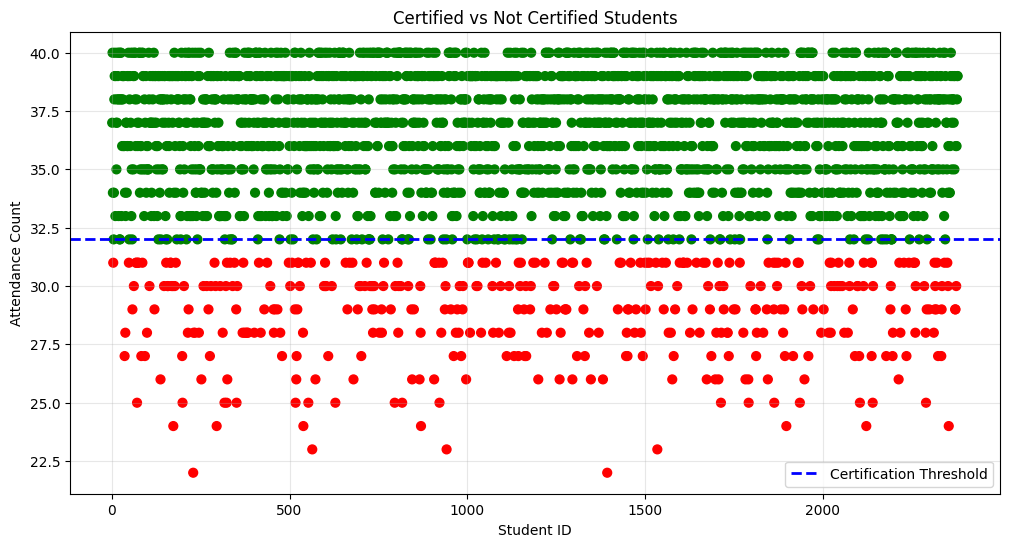


Files Saved Successfully!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

num_sessions = 40

attendance_records = {}

# ---------------------------------
# Read all 40 files
# ---------------------------------

for day in range(1, num_sessions + 1):

    file_name = f"Day{day}.xlsx"

    df = pd.read_excel(file_name)

    name_col = "Name (original name)"
    duration_col = "Duration (minutes).1"

    for _, row in df.iterrows():

        student = str(row[name_col]).strip()

        duration = row[duration_col]

        attendance = 1 if duration >= 30 else 0

        if student not in attendance_records:
            attendance_records[student] = [0] * num_sessions

        attendance_records[student][day - 1] = attendance

# ---------------------------------
# Create DataFrame
# ---------------------------------

attendance_df = pd.DataFrame.from_dict(
    attendance_records,
    orient="index"
)

attendance_df.reset_index(inplace=True)

attendance_df.rename(
    columns={"index": "Student_Name"},
    inplace=True
)

attendance_df.insert(
    0,
    "Student_ID",
    range(1, len(attendance_df) + 1)
)

# Rename session columns

for i in range(1, 41):
    attendance_df.rename(
        columns={i - 1: f"Session_{i}"},
        inplace=True
    )

session_columns = [
    f"Session_{i}"
    for i in range(1, 41)
]

# ---------------------------------
# Attendance Calculation
# ---------------------------------

attendance_df["Total_Attendance"] = (
    attendance_df[session_columns]
    .sum(axis=1)
)

attendance_df["Attendance_Percentage"] = (
    attendance_df["Total_Attendance"]
    / 40
) * 100

# ---------------------------------
# Certification
# ---------------------------------

attendance_df["Certification_Status"] = (
    attendance_df["Attendance_Percentage"]
    .apply(
        lambda x:
        "Certified"
        if x >= 80
        else "Not Certified"
    )
)

print("\nCertification Count:")
print(
    attendance_df["Certification_Status"]
    .value_counts()
)

# ---------------------------------
# Scatter Plot
# ---------------------------------

plt.figure(figsize=(12,6))

colors = attendance_df[
    "Certification_Status"
].map({
    "Certified": "green",
    "Not Certified": "red"
})

plt.scatter(
    attendance_df["Student_ID"],
    attendance_df["Total_Attendance"],
    c=colors,
    s=40
)

plt.axhline(
    y=32,
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Certification Threshold"
)

plt.xlabel("Student ID")
plt.ylabel("Attendance Count")
plt.title("Certified vs Not Certified Students")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

# ---------------------------------
# Save Outputs
# ---------------------------------

attendance_df.to_csv(
    "attendance_40_sessions.csv",
    index=False
)

attendance_df[
    attendance_df["Certification_Status"]
    == "Certified"
].to_csv(
    "certified_students.csv",
    index=False
)

attendance_df[
    attendance_df["Certification_Status"]
    == "Not Certified"
].to_csv(
    "not_certified_students.csv",
    index=False
)

print("\nFiles Saved Successfully!")